# **Pakistani Population Analysis**

**Author:** Hafiz Waseem Ahmed\
**Email:** waseemdevelopment2002@gmail.com \
**Github:** [waseem-development](https://github.com/waseem-development) 

## Source
[The data was collected from the following link:](https://www.kaggle.com/datasets/mabdullahsajid/population-of-pakistan-dataset)

## Years of Data
- 2017
- 1998

## Dataset Description
This dataset contains demographic information from the Pakistan Population Census conducted in 2017. It provides detailed population data at various administrative levels within Pakistan, including provinces, divisions, districts, and sub-divisions. The dataset also includes information on urban and rural populations, gender distribution, transgender individuals, sex ratios, population figures from the 1998 census, and annual growth rates.

## Features
- `Province`: The administrative provinces or regions of Pakistan where the census data was collected.
- `Division`: The divisions within each province. Divisions are the second level of administrative divisions in Pakistan.
- `District`: Districts within each division, representing larger administrative units.
- `Sub-Division`: Sub-divisions or tehsils within each district, providing more localized data.
- `Area`: The land area (in square kilometers) of each sub-division.
- `Urban Population 2017`: The population of urban areas within each sub-division for the year 2017.
- `Rural Population 2017`: The population of rural areas within each sub-division for the year 2017.
- `Male Population 2017`: The male population within each sub-division for the year 2017.
- `Female Population 2017`: The female population within each sub-division for the year 2017.
- `Transgender Population 2017`: The population of transgender individuals within each sub-division for the year 2017.
- `Sex Ratio 2017`: The sex ratio, calculated as the number of females per 1000 males, within each sub-division for the year 2017.
- `Population in 1998`: The total population of each sub-division as recorded in the 1998 census.
- `Annual Growth Rate`: The annual growth rate of the population in each sub-division, calculated as the percentage increase from 1998 to 2017.

## Data Source
The data in this dataset was collected from official Pakistan Population Census reports and may include data from various government sources. It is essential to provide proper attribution and reference the original sources when using this dataset for analysis or research.

## Data Usage
Researchers and analysts can use this dataset to explore demographic trends, population growth, urbanization rates, gender distribution, and more within Pakistan at different administrative levels. Ensure compliance with ethical and legal guidelines when using this data for research or public sharing.

> **Note**: This description is a template. Please adapt it based on the actual data sources and specific details of your dataset when creating it for Kaggle or any other platform.

## Purpose of this Analysis
*We will fill this at the end or during process*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./datasets/population.csv")

### Data Composition

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PROVINCE                    528 non-null    str    
 1   DIVISION                    528 non-null    str    
 2   DISTRICT                    528 non-null    str    
 3   SUB DIVISION                528 non-null    str    
 4   AREA (sq.km)                528 non-null    float64
 5   ALL SEXES (RURAL)           528 non-null    int64  
 6   MALE (RURAL)                528 non-null    int64  
 7   FEMALE (RURAL)              528 non-null    int64  
 8   TRANSGENDER (RURAL)         528 non-null    int64  
 9   SEX RATIO (RURAL)           528 non-null    float64
 10  AVG HOUSEHOLD SIZE (RURAL)  528 non-null    float64
 11  POPULATION 1998 (RURAL)     528 non-null    int64  
 12  ANNUAL GROWTH RATE (RURAL)  528 non-null    float64
 13  ALL SEXES (URBAN)           528 non-null    in

In [4]:
df.shape

(528, 21)

In [5]:
df.describe()

,AREA (sq.km),ALL SEXES (RURAL),MALE (RURAL),FEMALE (RURAL),TRANSGENDER (RURAL),SEX RATIO (RURAL),AVG HOUSEHOLD SIZE (RURAL),POPULATION 1998 (RURAL),ANNUAL GROWTH RATE (RURAL),ALL SEXES (URBAN),MALE (URBAN),FEMALE (URBAN),TRANSGENDER (URBAN),SEX RATIO (URBAN),AVG HOUSEHOLD SIZE (URBAN),POPULATION 1998 (URBAN),ANNUAL GROWTH RATE (URBAN)
count,528.000000,5.280000e+02,5.280000e+02,5.280000e+02,528.000000,528.000000,528.000000,5.280000e+02,528.000000,5.280000e+02,5.280000e+02,5.280000e+02,528.000000,528.000000,528.000000,5.280000e+02,528.000000
mean,1492.005871,2.462780e+05,1.252757e+05,1.209841e+05,18.174242,98.982614,6.277064,1.674280e+05,3.124792,1.408635e+05,7.284339e+04,6.799787e+04,22.276515,75.411269,4.406402,8.014457e+04,1.920814
std,2039.453778,2.711898e+05,1.375630e+05,1.337169e+05,25.522248,26.812660,2.074947,1.783890e+05,9.577872,3.512463e+05,1.823492e+05,1.688725e+05,66.068127,49.687341,2.948336,2.023120e+05,2.098908
min,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,425.000000,5.093450e+04,2.712725e+04,2.397900e+04,1.000000,101.105000,5.700000,3.527350e+04,1.440000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000
50%,882.000000,1.652410e+05,8.413450e+04,8.204400e+04,10.000000,105.285000,6.310000,1.172065e+05,2.030000,4.325450e+04,2.198000e+04,2.099900e+04,3.000000,103.195000,5.755000,2.129800e+04,1.855000
75%,1734.250000,3.129112e+05,1.605022e+05,1.522190e+05,25.000000,108.347500,7.200000,2.130542e+05,2.812500,1.178148e+05,6.030175e+04,5.746525e+04,19.000000,107.040000,6.340000,6.542225e+04,2.985000
max,18374.000000,2.297375e+06,1.172995e+06,1.124167e+06,213.000000,139.380000,12.430000,1.044035e+06,100.000000,3.653616e+06,1.905921e+06,1.746900e+06,795.000000,297.810000,10.060000,2.075867e+06,19.780000


In [6]:
df.head()

,PROVINCE,DIVISION,DISTRICT,SUB DIVISION,AREA (sq.km),ALL SEXES (RURAL),MALE (RURAL),FEMALE (RURAL),TRANSGENDER (RURAL),SEX RATIO (RURAL),...,POPULATION 1998 (RURAL),ANNUAL GROWTH RATE (RURAL),ALL SEXES (URBAN),MALE (URBAN),FEMALE (URBAN),TRANSGENDER (URBAN),SEX RATIO (URBAN),AVG HOUSEHOLD SIZE (URBAN),POPULATION 1998 (URBAN),ANNUAL GROWTH RATE (URBAN)
0,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,BAHAWALNAGAR TEHSIL,1729.0,619550,316864,302644,42,104.70,...,407768,2.22,193840,98391,95402,47,103.13,6.02,133785,1.97
1,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,CHISHTIAN TEHSIL,1500.0,540342,273788,266500,54,102.73,...,395983,1.65,149424,75546,73851,27,102.30,6.01,102287,2.01
2,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,FORT ABBAS TEHSIL,2536.0,361240,182655,178541,44,102.30,...,250959,1.93,61528,31360,30150,18,104.01,6.00,34637,3.06
3,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,HAROONABAD TEHSIL,1295.0,382115,192278,189808,29,101.30,...,297343,1.33,142600,71345,71236,19,100.15,6.02,84424,2.79
4,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,MINCHINABAD TEHSIL,1818.0,452723,231506,221178,39,104.67,...,316593,1.90,72294,36694,35590,10,103.10,6.34,37668,3.48


In [7]:
pd.set_option("display.max_columns", None)

### How many are the missing Values

In [8]:
df.isnull().sum()

PROVINCE                      0
DIVISION                      0
DISTRICT                      0
SUB DIVISION                  0
AREA (sq.km)                  0
ALL SEXES (RURAL)             0
MALE (RURAL)                  0
FEMALE (RURAL)                0
TRANSGENDER (RURAL)           0
SEX RATIO (RURAL)             0
AVG HOUSEHOLD SIZE (RURAL)    0
POPULATION 1998 (RURAL)       0
ANNUAL GROWTH RATE (RURAL)    0
ALL SEXES (URBAN)             0
MALE (URBAN)                  0
FEMALE (URBAN)                0
TRANSGENDER (URBAN)           0
SEX RATIO (URBAN)             0
AVG HOUSEHOLD SIZE (URBAN)    0
POPULATION 1998 (URBAN)       0
ANNUAL GROWTH RATE (URBAN)    0
dtype: int64

### Hypothesis

In [9]:
df_columns = df.columns.tolist()

for i in range(0, len(df_columns), 2):
    col1 = df_columns[i]
    col2 = df_columns[i+1] if i+1 < len(df_columns) else ""

    print(f"{col1:<35} {col2:<35}")

PROVINCE                            DIVISION                           
DISTRICT                            SUB DIVISION                       
AREA (sq.km)                        ALL SEXES (RURAL)                  
MALE (RURAL)                        FEMALE (RURAL)                     
TRANSGENDER (RURAL)                 SEX RATIO (RURAL)                  
AVG HOUSEHOLD SIZE (RURAL)          POPULATION 1998 (RURAL)            
ANNUAL GROWTH RATE (RURAL)          ALL SEXES (URBAN)                  
MALE (URBAN)                        FEMALE (URBAN)                     
TRANSGENDER (URBAN)                 SEX RATIO (URBAN)                  
AVG HOUSEHOLD SIZE (URBAN)          POPULATION 1998 (URBAN)            
ANNUAL GROWTH RATE (URBAN)                                             


In [10]:
num_cols = df.select_dtypes(include=["number"]).columns
num_cols

Index(['AREA (sq.km)', 'ALL SEXES (RURAL)', 'MALE (RURAL)', 'FEMALE (RURAL)',
       'TRANSGENDER (RURAL)', 'SEX RATIO (RURAL)',
       'AVG HOUSEHOLD SIZE (RURAL)', 'POPULATION 1998 (RURAL)',
       'ANNUAL GROWTH RATE (RURAL)', 'ALL SEXES (URBAN)', 'MALE (URBAN)',
       'FEMALE (URBAN)', 'TRANSGENDER (URBAN)', 'SEX RATIO (URBAN)',
       'AVG HOUSEHOLD SIZE (URBAN)', 'POPULATION 1998 (URBAN)',
       'ANNUAL GROWTH RATE (URBAN)'],
      dtype='str')

<Axes: ylabel='AREA (sq.km)'>

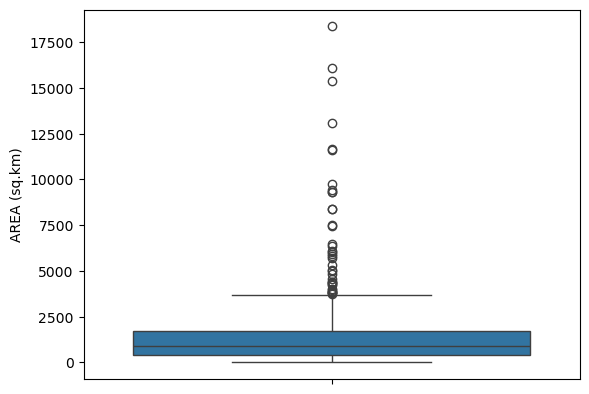

In [11]:
sns.boxplot(df, y="AREA (sq.km)")

In [12]:
df_copy = df.copy()

<Axes: ylabel='ALL SEXES (RURAL)'>

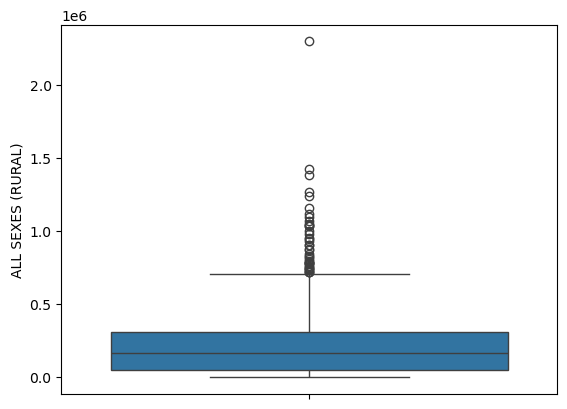

In [13]:
sns.boxplot(df_copy, y="ALL SEXES (RURAL)")

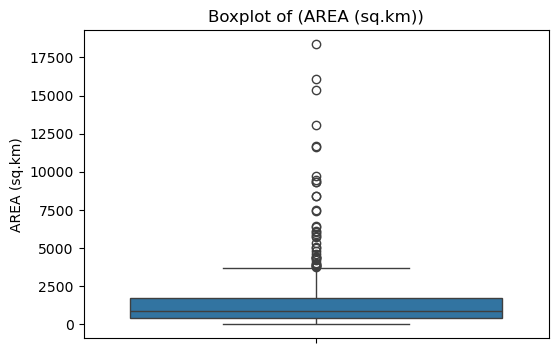

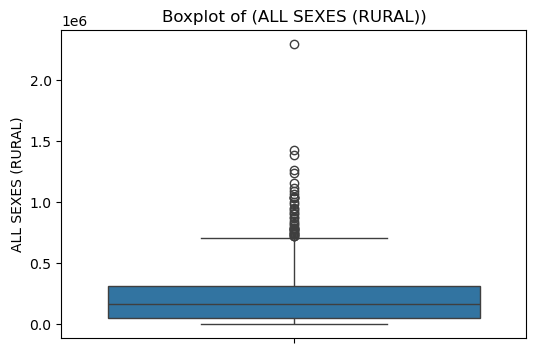

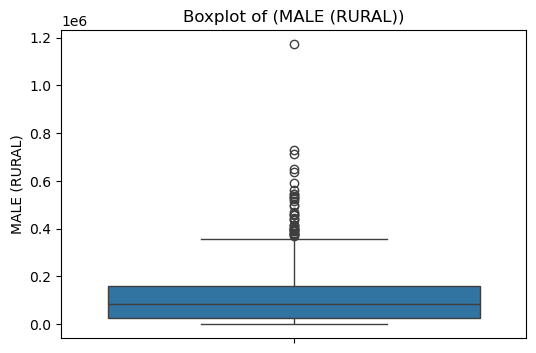

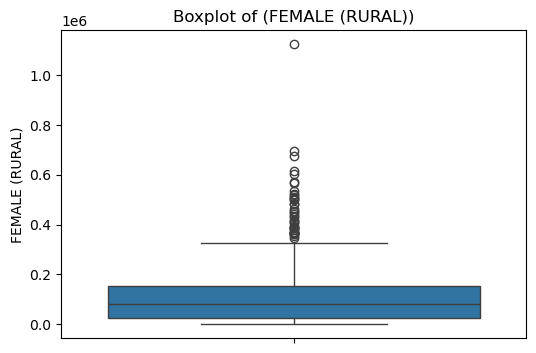

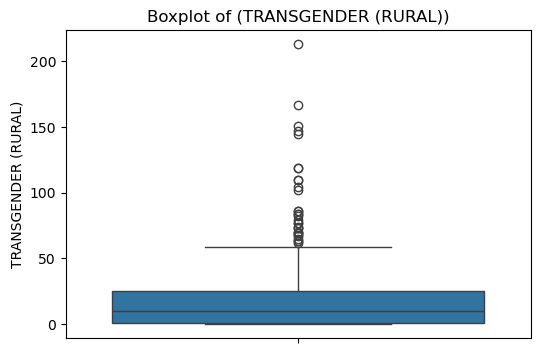

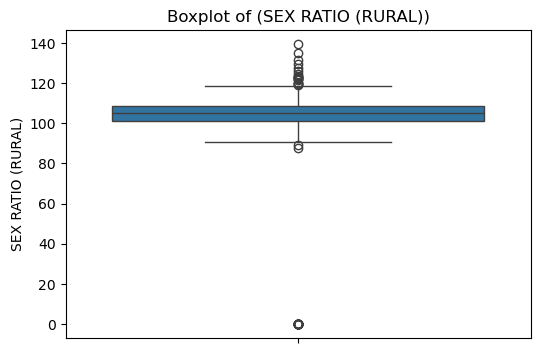

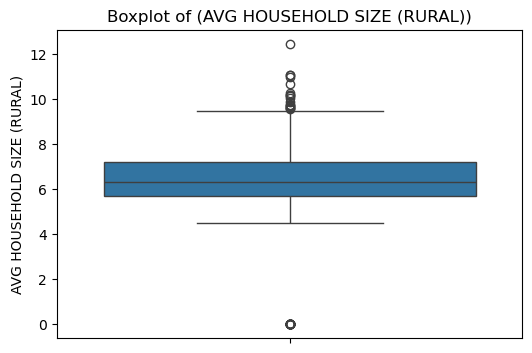

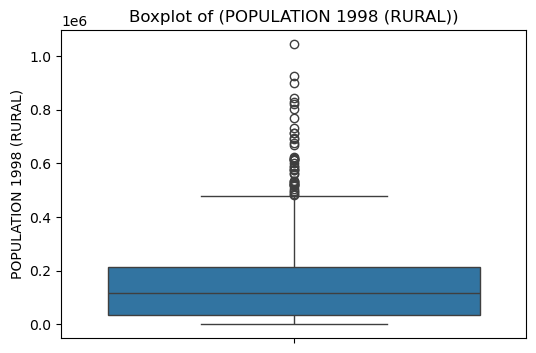

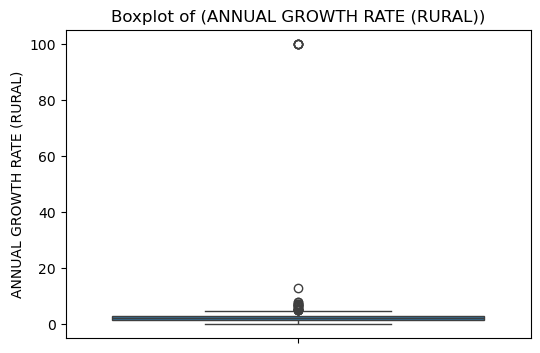

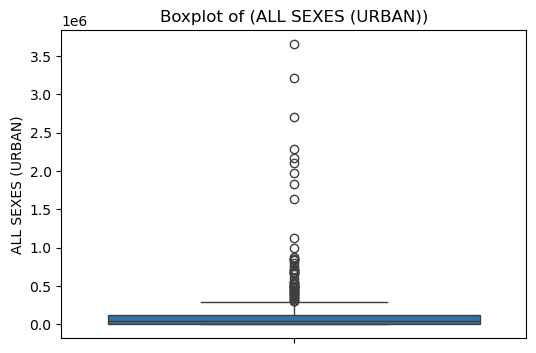

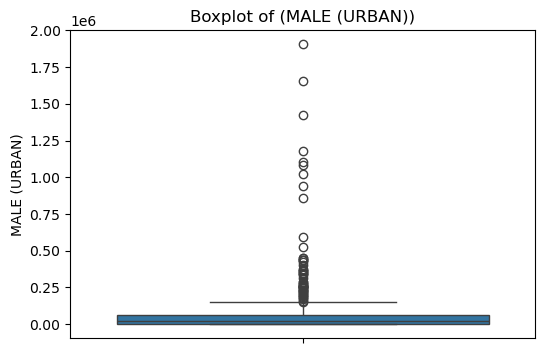

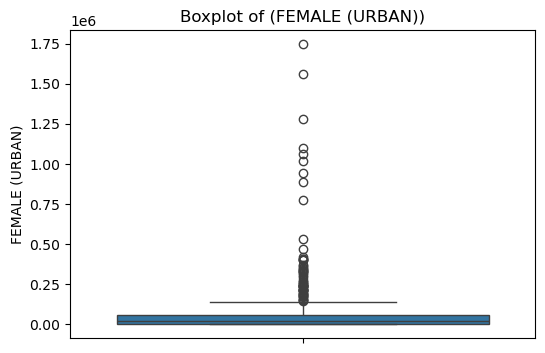

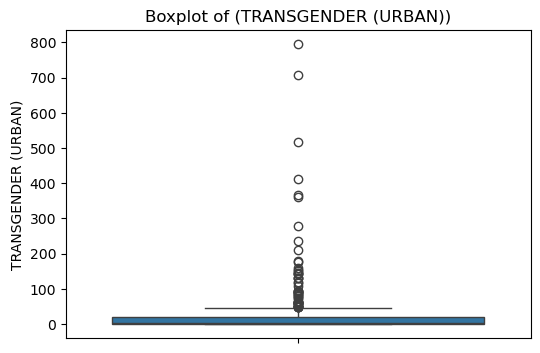

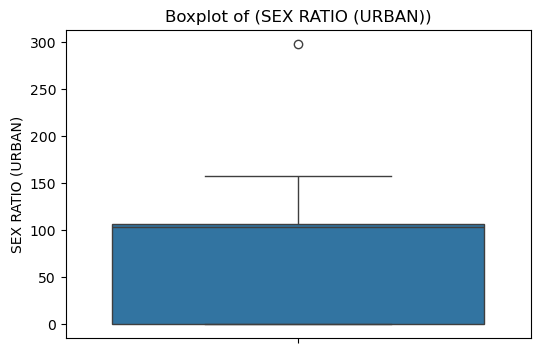

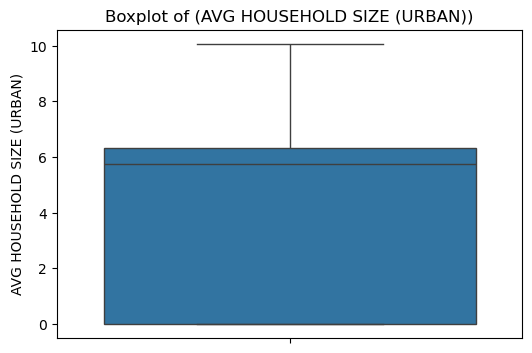

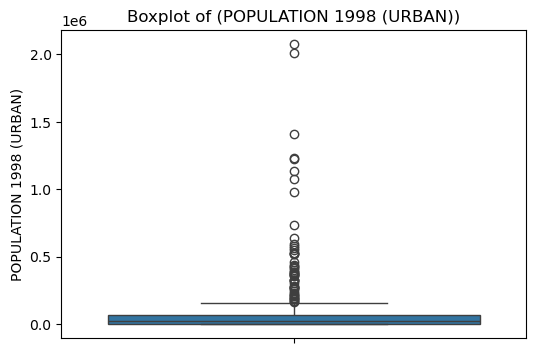

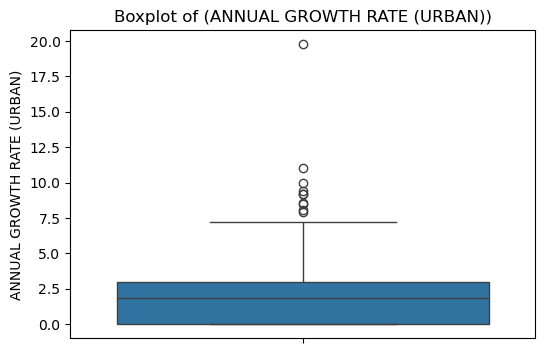

In [14]:
num_cols = df_copy.select_dtypes(include="number").columns

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_copy, y=col)
    plt.title(f"Boxplot of ({col})")
    plt.show()

### Remove Outliers

In [15]:
def clean_data_from_outliers(col):
    data = df_copy[col]

    print(f"\n{'='*50}")
    print(f"📊 Processing Column: {col}")
    print(f"{'='*50}")

    # 5-number summary
    minimum = data.min()
    q1 = data.quantile(0.25)
    median = data.median()
    q3 = data.quantile(0.75)
    maximum = data.max()

    print(f"{col} → Minimum: {minimum}")
    print(f"{col} → Q1: {q1}")
    print(f"{col} → Median: {median}")
    print(f"{col} → Q3: {q3}")
    print(f"{col} → Maximum: {maximum}")

    # IQR
    iqr = q3 - q1
    print(f"{col} → IQR: {iqr}")

    # Bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    print(f"{col} → Lower Bound: {lower_bound}")
    print(f"{col} → Upper Bound: {upper_bound}")

    # Outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    print(f"{col} → Outliers Count: {len(outliers)}")

    # ── Styling ──────────────────────────────────────────
    BEFORE_COLOR = "#4C72B0"
    AFTER_COLOR  = "#55A868"
    BG_COLOR     = "#F8F9FA"

    sns.set_style("whitegrid")
    plt.rcParams.update({
        "axes.facecolor":  BG_COLOR,
        "figure.facecolor": BG_COLOR,
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "axes.spines.left":   False,
        "axes.spines.bottom": False,
        "grid.color": "#E0E0E0",
        "grid.linewidth": 0.8,
    })

    def _plot_pair(series, color, label):
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        fig.patch.set_facecolor(BG_COLOR)
        fig.suptitle(
            f"{label}  ·  {col}",
            fontsize=13, fontweight="bold", color="#2d2d2d", y=1.02
        )

        # Boxplot
        sns.boxplot(
            y=series, ax=axes[0],
            color=color,
            linewidth=1.4,
            flierprops=dict(marker="o", markerfacecolor=color,
                            markersize=4, alpha=0.5, linestyle="none"),
            boxprops=dict(alpha=0.85),
        )
        axes[0].set_title("Distribution", fontsize=10, color="#555")
        axes[0].set_ylabel("")
        axes[0].tick_params(labelsize=9)

        # Histogram
        sns.histplot(
            series, kde=True, bins=30, ax=axes[1],
            color=color, alpha=0.75,
            line_kws={"linewidth": 2},
        )
        axes[1].set_title("Frequency", fontsize=10, color="#555")
        axes[1].set_xlabel("")
        axes[1].tick_params(labelsize=9)

        plt.tight_layout()
        plt.show()

    # 🔹 BEFORE
    _plot_pair(data, BEFORE_COLOR, "🔴 Before Cleaning")

    # Clean
    df_copy[col] = data.clip(lower_bound, upper_bound)

    # 🔹 AFTER
    _plot_pair(df_copy[col], AFTER_COLOR, "🟢 After Cleaning")





📊 Processing Column: AREA (sq.km)
AREA (sq.km) → Minimum: 0.0
AREA (sq.km) → Q1: 425.0
AREA (sq.km) → Median: 882.0
AREA (sq.km) → Q3: 1734.25
AREA (sq.km) → Maximum: 18374.0
AREA (sq.km) → IQR: 1309.25
AREA (sq.km) → Lower Bound: -1538.875
AREA (sq.km) → Upper Bound: 3698.125
AREA (sq.km) → Outliers Count: 38


/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


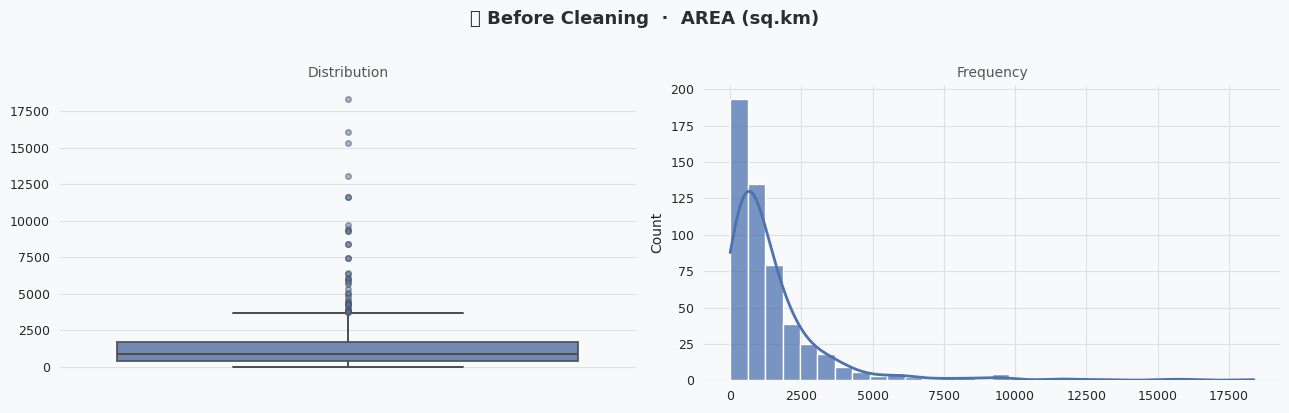

/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


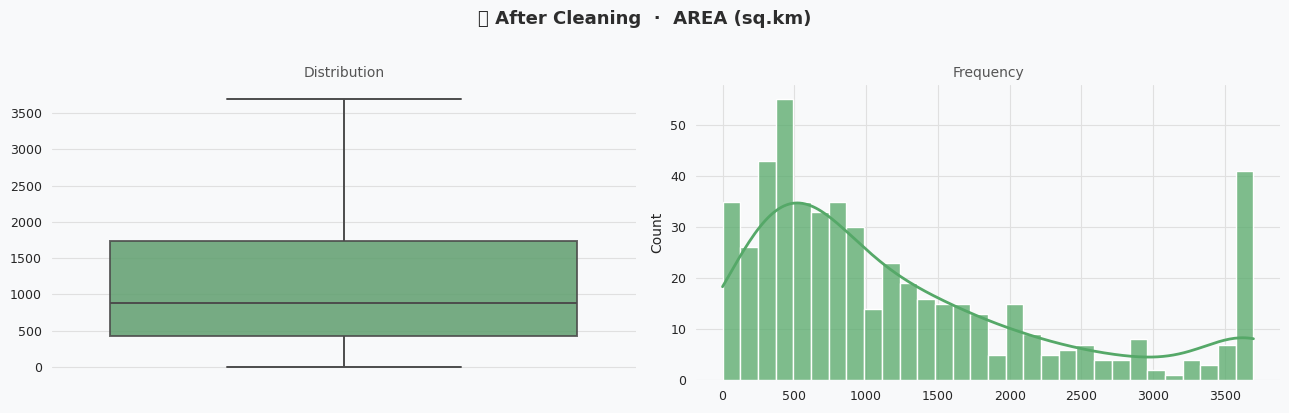


📊 Processing Column: ALL SEXES (RURAL)
ALL SEXES (RURAL) → Minimum: 0
ALL SEXES (RURAL) → Q1: 50934.5
ALL SEXES (RURAL) → Median: 165241.0
ALL SEXES (RURAL) → Q3: 312911.25
ALL SEXES (RURAL) → Maximum: 2297375
ALL SEXES (RURAL) → IQR: 261976.75
ALL SEXES (RURAL) → Lower Bound: -342030.625
ALL SEXES (RURAL) → Upper Bound: 705876.375
ALL SEXES (RURAL) → Outliers Count: 41


/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


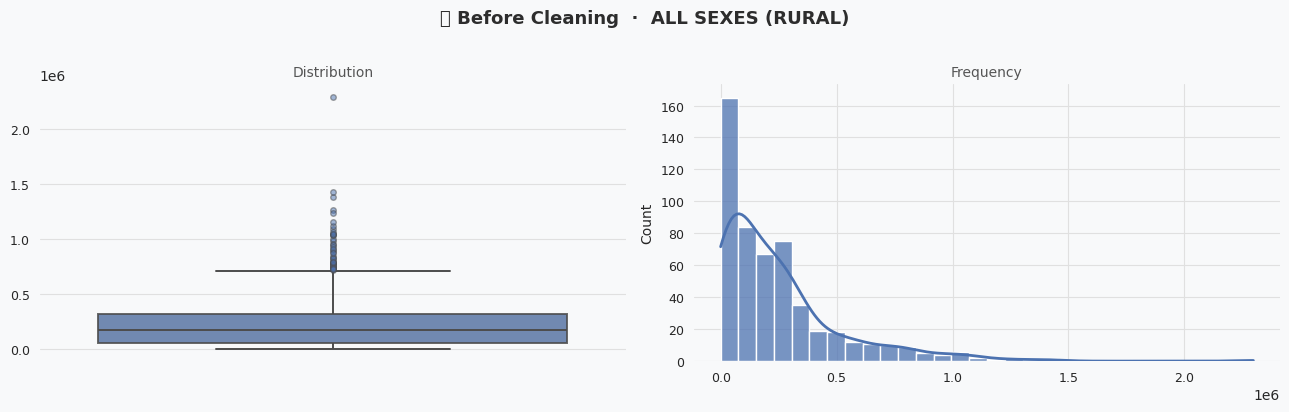

/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


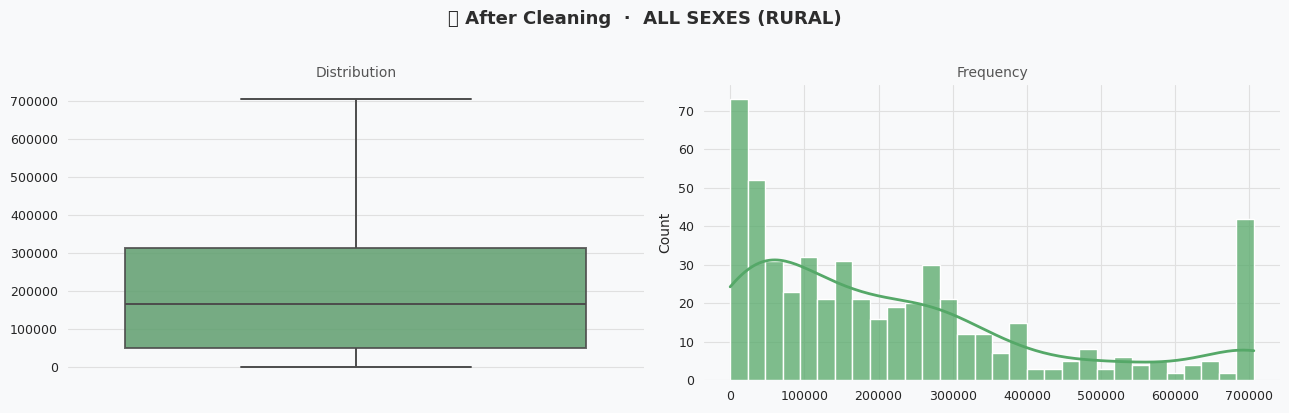


📊 Processing Column: MALE (RURAL)
MALE (RURAL) → Minimum: 0
MALE (RURAL) → Q1: 27127.25
MALE (RURAL) → Median: 84134.5
MALE (RURAL) → Q3: 160502.25
MALE (RURAL) → Maximum: 1172995
MALE (RURAL) → IQR: 133375.0
MALE (RURAL) → Lower Bound: -172935.25
MALE (RURAL) → Upper Bound: 360564.75
MALE (RURAL) → Outliers Count: 39


/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


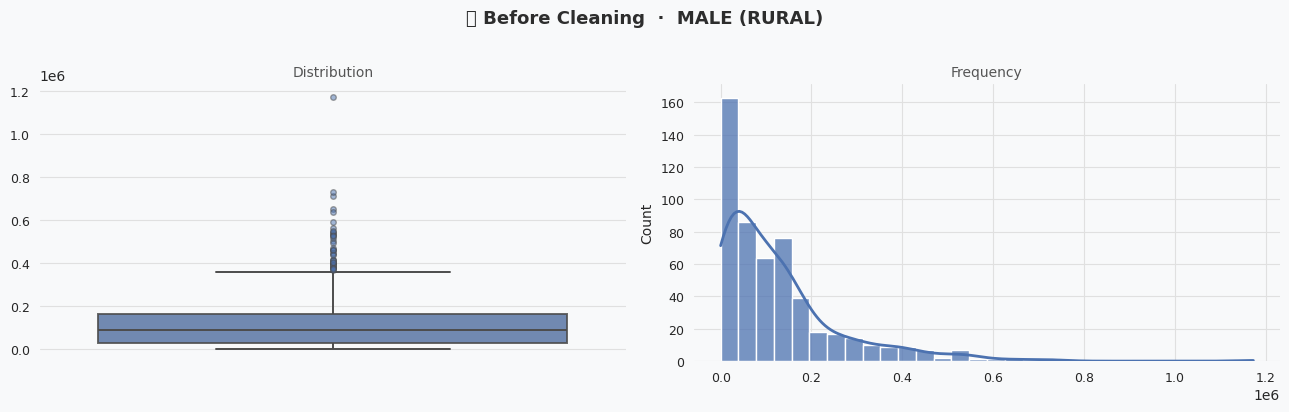

/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


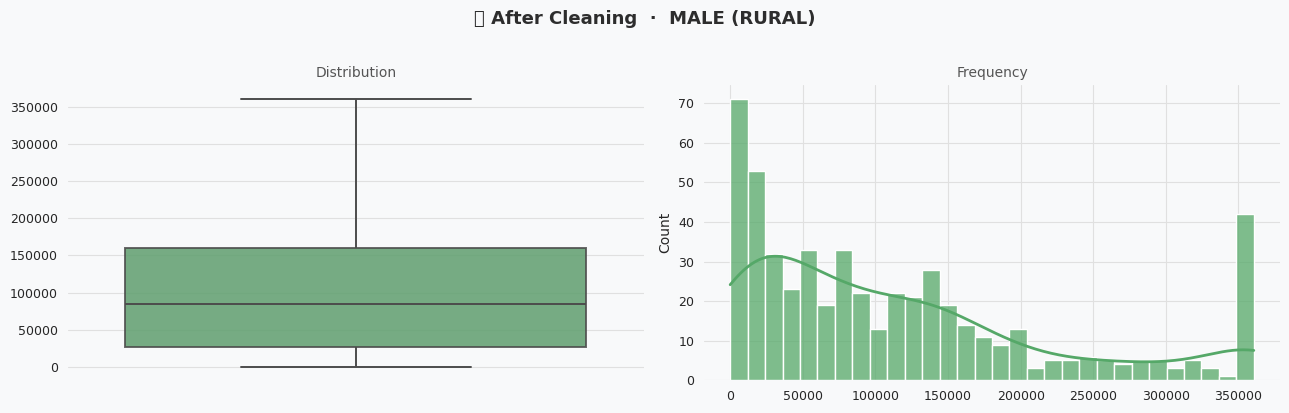


📊 Processing Column: FEMALE (RURAL)
FEMALE (RURAL) → Minimum: 0
FEMALE (RURAL) → Q1: 23979.0
FEMALE (RURAL) → Median: 82044.0
FEMALE (RURAL) → Q3: 152219.0
FEMALE (RURAL) → Maximum: 1124167
FEMALE (RURAL) → IQR: 128240.0
FEMALE (RURAL) → Lower Bound: -168381.0
FEMALE (RURAL) → Upper Bound: 344579.0
FEMALE (RURAL) → Outliers Count: 42


/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


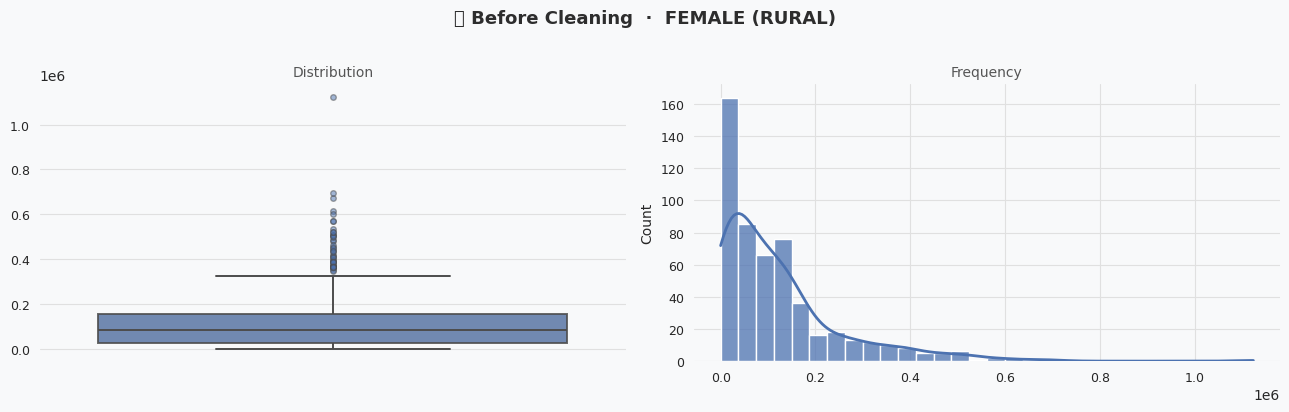

/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


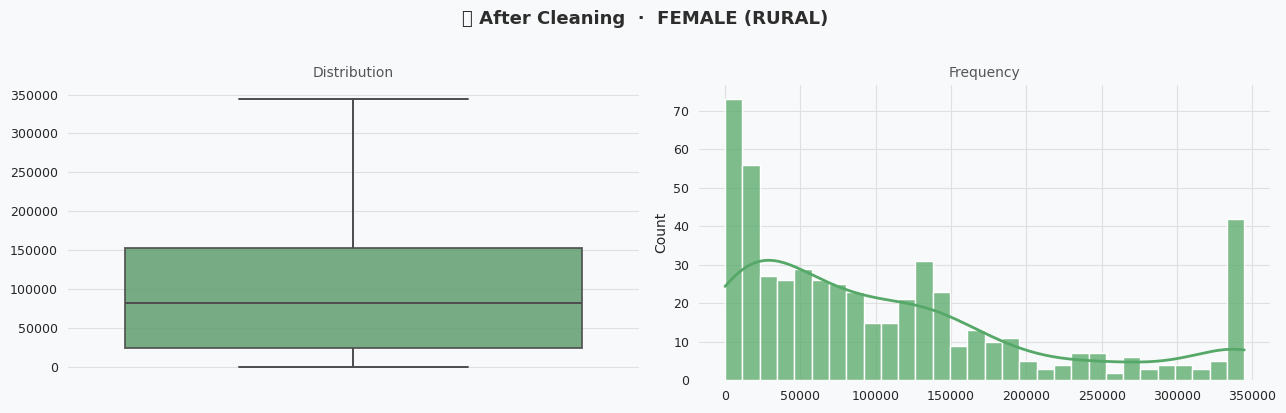


📊 Processing Column: TRANSGENDER (RURAL)
TRANSGENDER (RURAL) → Minimum: 0
TRANSGENDER (RURAL) → Q1: 1.0
TRANSGENDER (RURAL) → Median: 10.0
TRANSGENDER (RURAL) → Q3: 25.0
TRANSGENDER (RURAL) → Maximum: 213
TRANSGENDER (RURAL) → IQR: 24.0
TRANSGENDER (RURAL) → Lower Bound: -35.0
TRANSGENDER (RURAL) → Upper Bound: 61.0
TRANSGENDER (RURAL) → Outliers Count: 31


/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


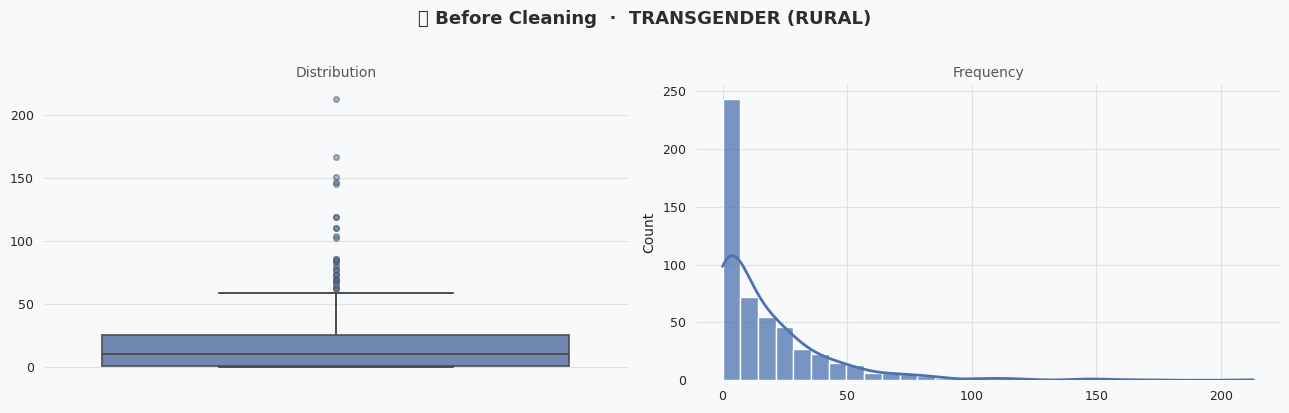

/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


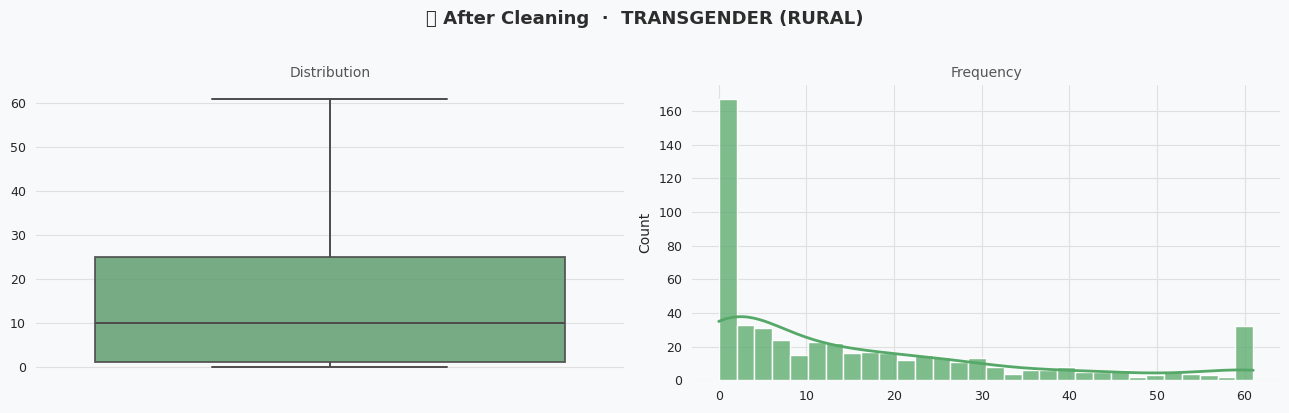


📊 Processing Column: SEX RATIO (RURAL)
SEX RATIO (RURAL) → Minimum: 0.0
SEX RATIO (RURAL) → Q1: 101.105
SEX RATIO (RURAL) → Median: 105.285
SEX RATIO (RURAL) → Q3: 108.3475
SEX RATIO (RURAL) → Maximum: 139.38
SEX RATIO (RURAL) → IQR: 7.242499999999993
SEX RATIO (RURAL) → Lower Bound: 90.24125000000001
SEX RATIO (RURAL) → Upper Bound: 119.21124999999998
SEX RATIO (RURAL) → Outliers Count: 56


/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


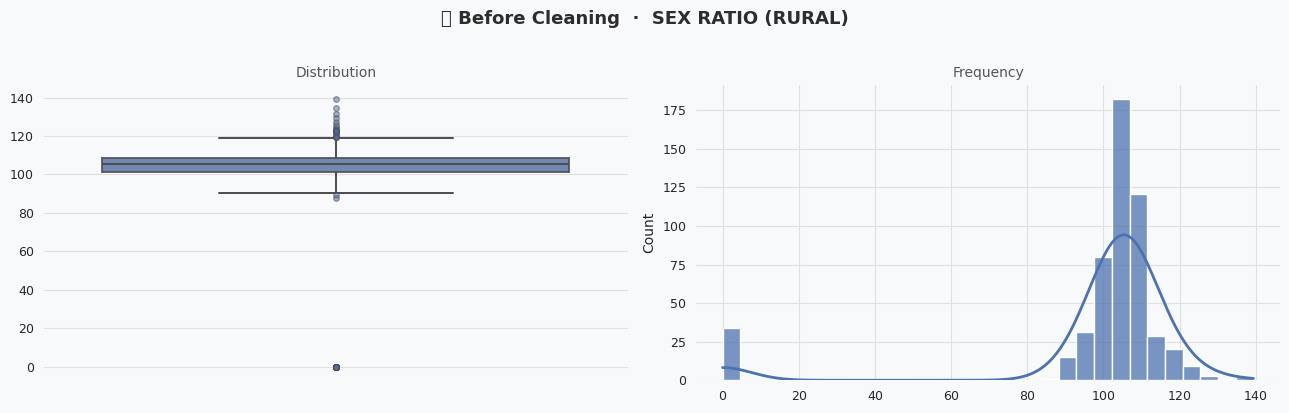

/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


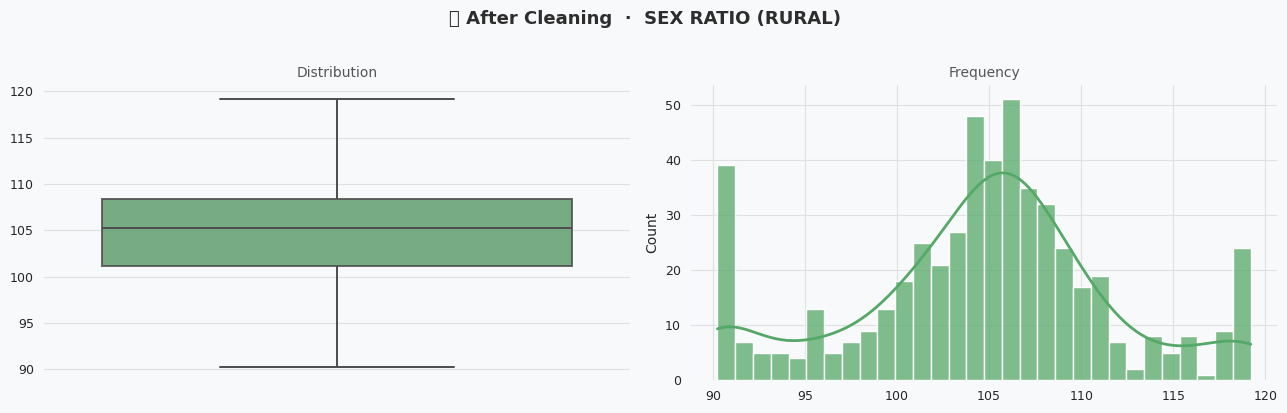


📊 Processing Column: AVG HOUSEHOLD SIZE (RURAL)
AVG HOUSEHOLD SIZE (RURAL) → Minimum: 0.0
AVG HOUSEHOLD SIZE (RURAL) → Q1: 5.7
AVG HOUSEHOLD SIZE (RURAL) → Median: 6.31
AVG HOUSEHOLD SIZE (RURAL) → Q3: 7.2
AVG HOUSEHOLD SIZE (RURAL) → Maximum: 12.43
AVG HOUSEHOLD SIZE (RURAL) → IQR: 1.5
AVG HOUSEHOLD SIZE (RURAL) → Lower Bound: 3.45
AVG HOUSEHOLD SIZE (RURAL) → Upper Bound: 9.45
AVG HOUSEHOLD SIZE (RURAL) → Outliers Count: 52


/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


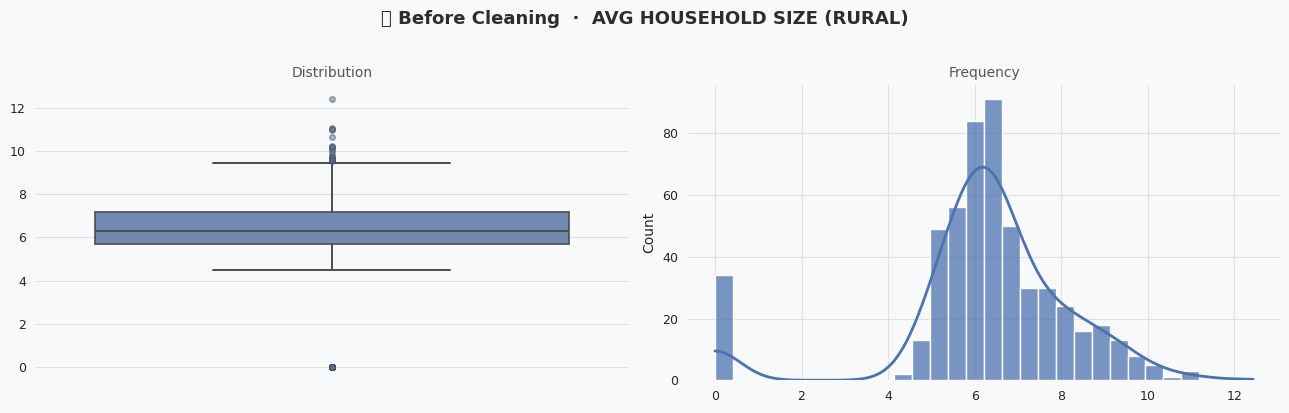

/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


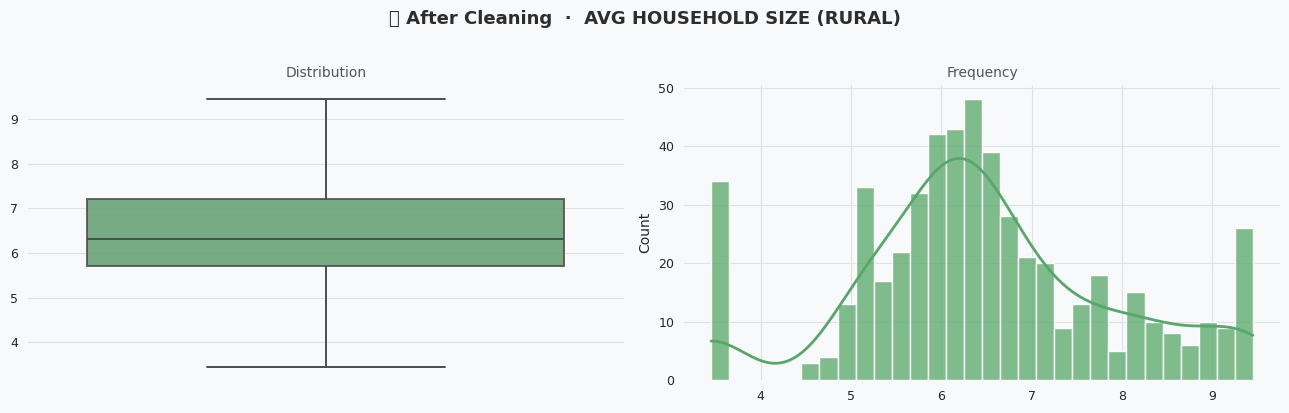


📊 Processing Column: POPULATION 1998 (RURAL)
POPULATION 1998 (RURAL) → Minimum: 0
POPULATION 1998 (RURAL) → Q1: 35273.5
POPULATION 1998 (RURAL) → Median: 117206.5
POPULATION 1998 (RURAL) → Q3: 213054.25
POPULATION 1998 (RURAL) → Maximum: 1044035
POPULATION 1998 (RURAL) → IQR: 177780.75
POPULATION 1998 (RURAL) → Lower Bound: -231397.625
POPULATION 1998 (RURAL) → Upper Bound: 479725.375
POPULATION 1998 (RURAL) → Outliers Count: 43


/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


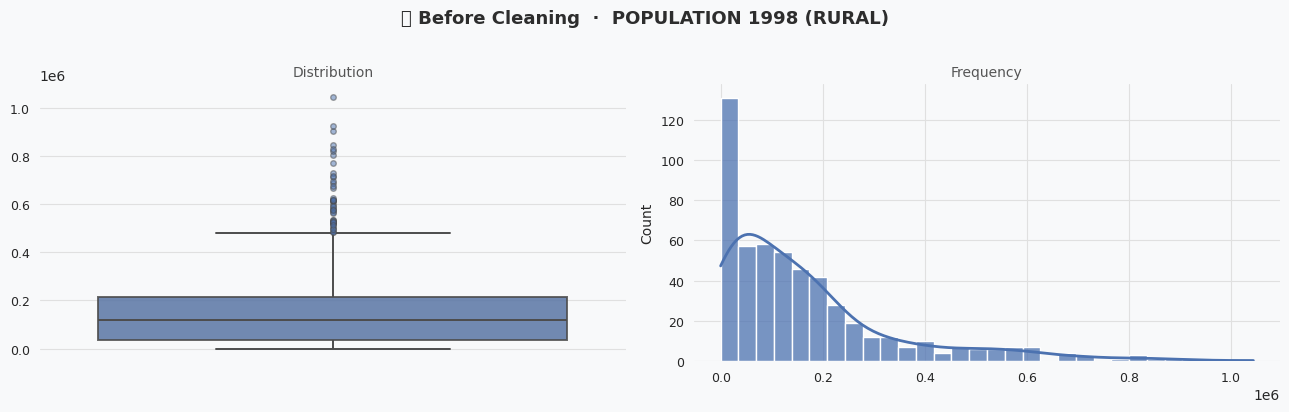

/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


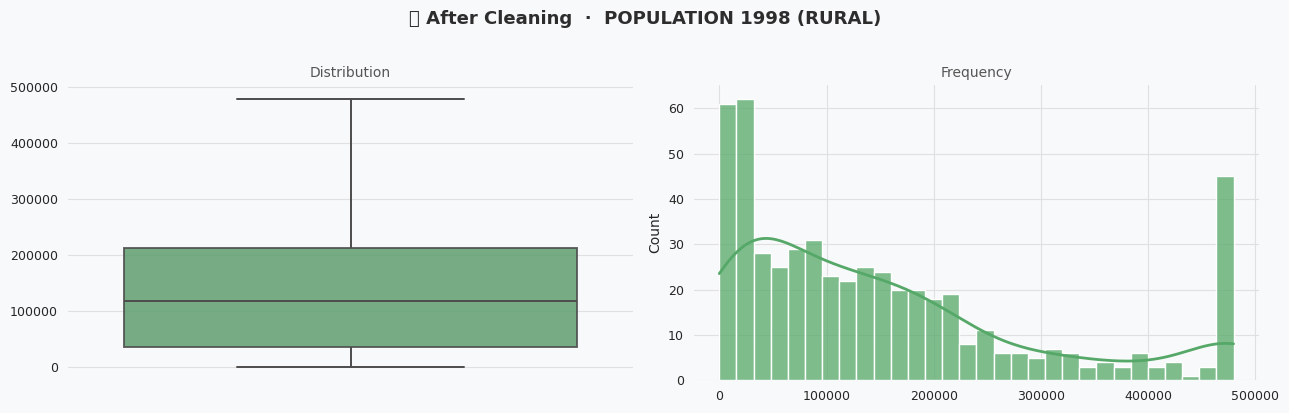


📊 Processing Column: ANNUAL GROWTH RATE (RURAL)
ANNUAL GROWTH RATE (RURAL) → Minimum: 0.0
ANNUAL GROWTH RATE (RURAL) → Q1: 1.44
ANNUAL GROWTH RATE (RURAL) → Median: 2.03
ANNUAL GROWTH RATE (RURAL) → Q3: 2.8125
ANNUAL GROWTH RATE (RURAL) → Maximum: 100.0
ANNUAL GROWTH RATE (RURAL) → IQR: 1.3725
ANNUAL GROWTH RATE (RURAL) → Lower Bound: -0.6187499999999999
ANNUAL GROWTH RATE (RURAL) → Upper Bound: 4.87125
ANNUAL GROWTH RATE (RURAL) → Outliers Count: 25


/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


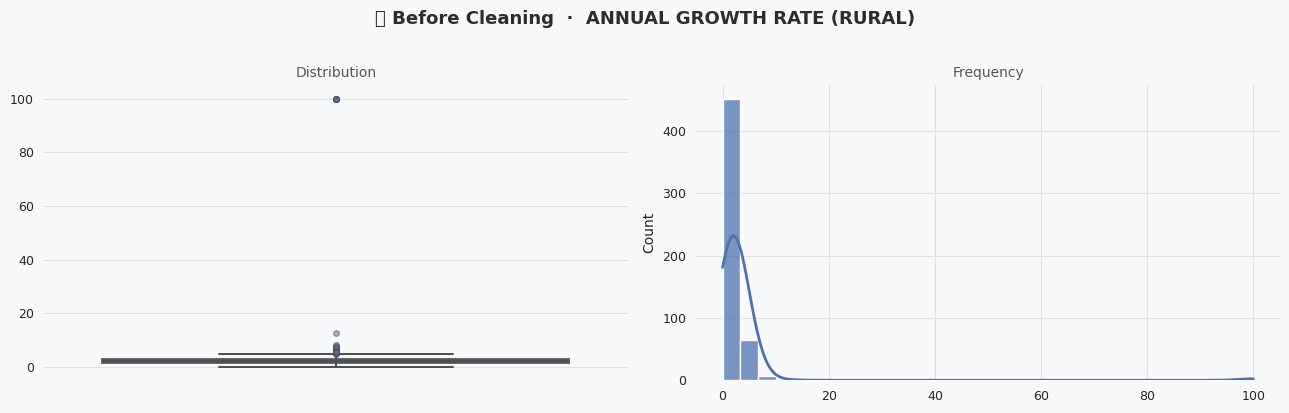

/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


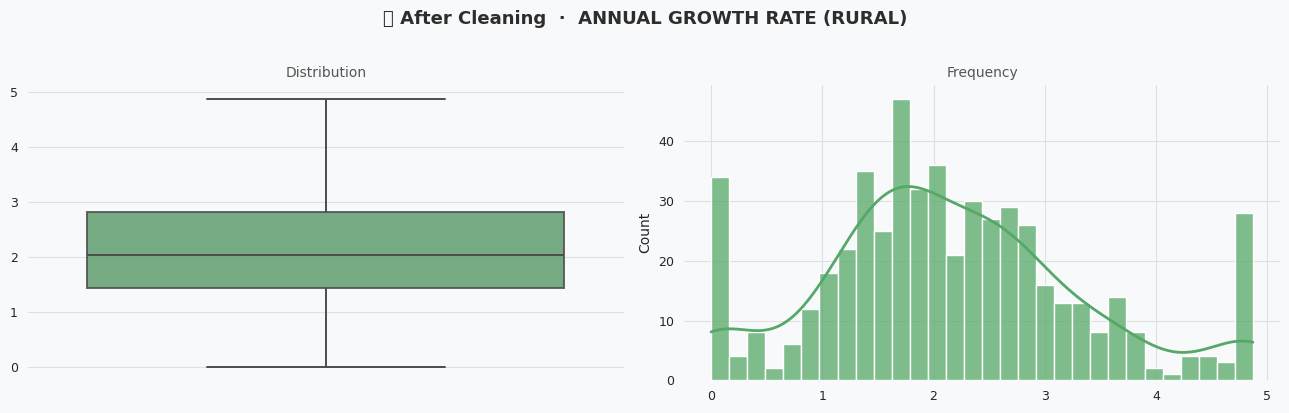


📊 Processing Column: ALL SEXES (URBAN)
ALL SEXES (URBAN) → Minimum: 0
ALL SEXES (URBAN) → Q1: 0.0
ALL SEXES (URBAN) → Median: 43254.5
ALL SEXES (URBAN) → Q3: 117814.75
ALL SEXES (URBAN) → Maximum: 3653616
ALL SEXES (URBAN) → IQR: 117814.75
ALL SEXES (URBAN) → Lower Bound: -176722.125
ALL SEXES (URBAN) → Upper Bound: 294536.875
ALL SEXES (URBAN) → Outliers Count: 55


/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


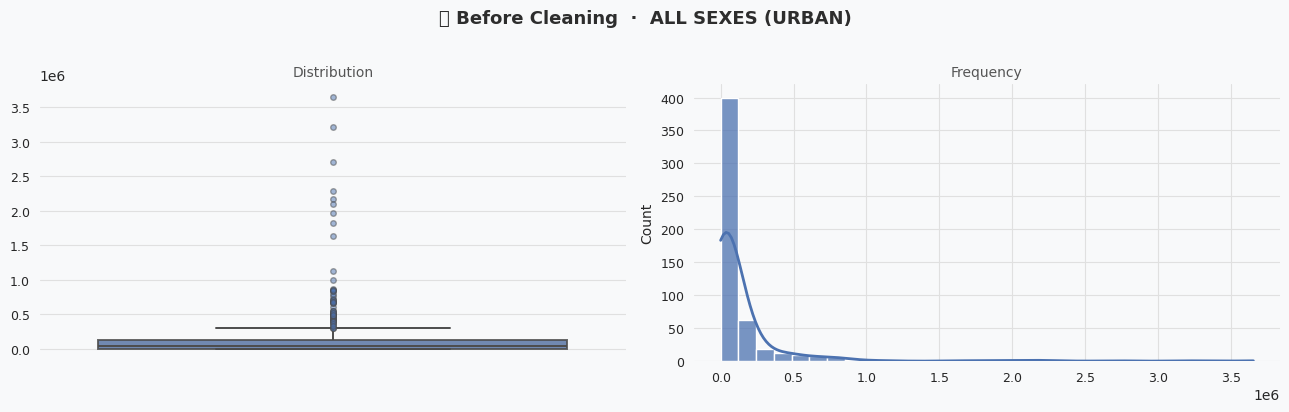

/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


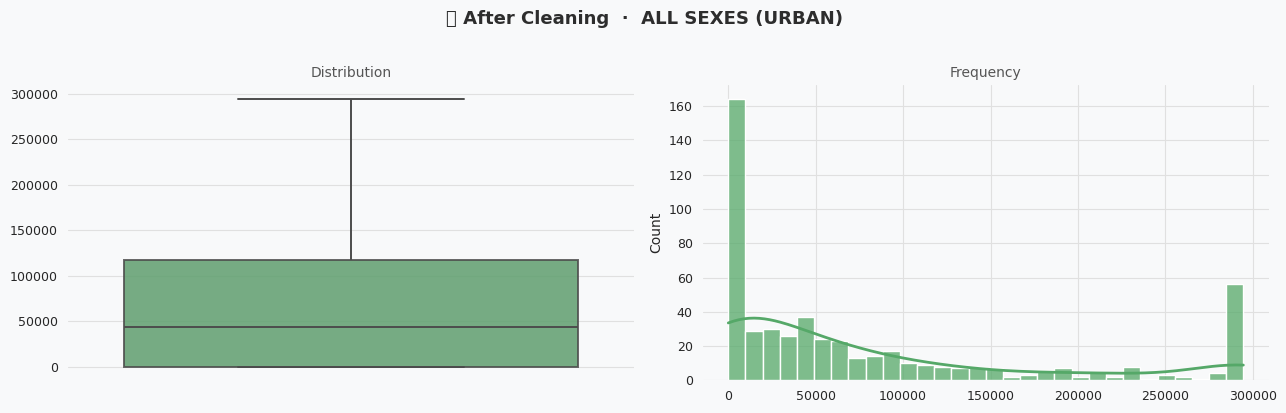


📊 Processing Column: MALE (URBAN)
MALE (URBAN) → Minimum: 0
MALE (URBAN) → Q1: 0.0
MALE (URBAN) → Median: 21980.0
MALE (URBAN) → Q3: 60301.75
MALE (URBAN) → Maximum: 1905921
MALE (URBAN) → IQR: 60301.75
MALE (URBAN) → Lower Bound: -90452.625
MALE (URBAN) → Upper Bound: 150754.375
MALE (URBAN) → Outliers Count: 54


/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


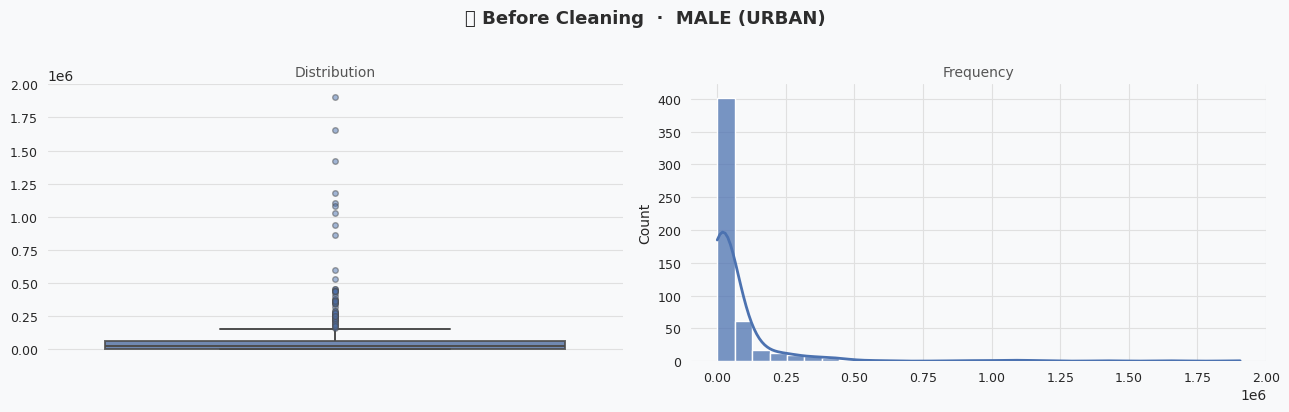

/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


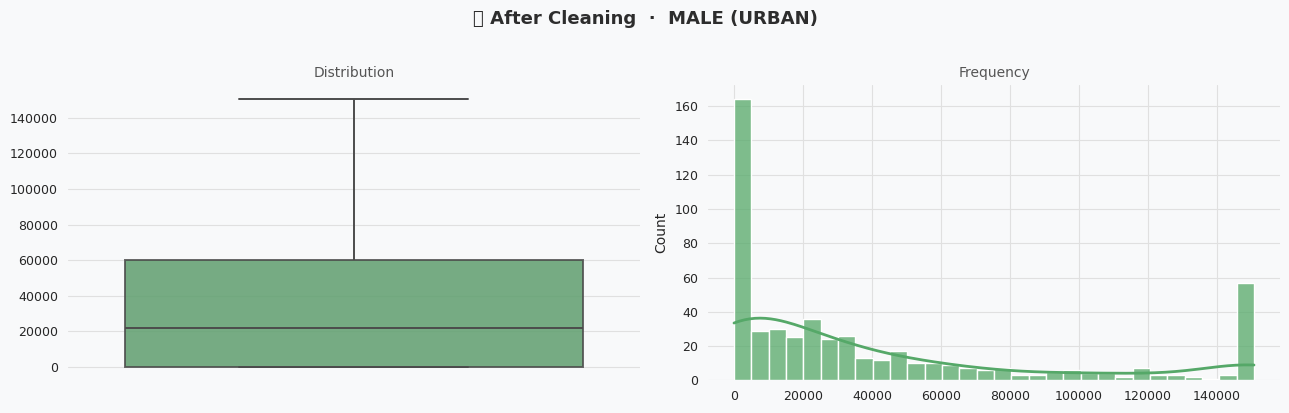


📊 Processing Column: FEMALE (URBAN)
FEMALE (URBAN) → Minimum: 0
FEMALE (URBAN) → Q1: 0.0
FEMALE (URBAN) → Median: 20999.0
FEMALE (URBAN) → Q3: 57465.25
FEMALE (URBAN) → Maximum: 1746900
FEMALE (URBAN) → IQR: 57465.25
FEMALE (URBAN) → Lower Bound: -86197.875
FEMALE (URBAN) → Upper Bound: 143663.125
FEMALE (URBAN) → Outliers Count: 55


/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


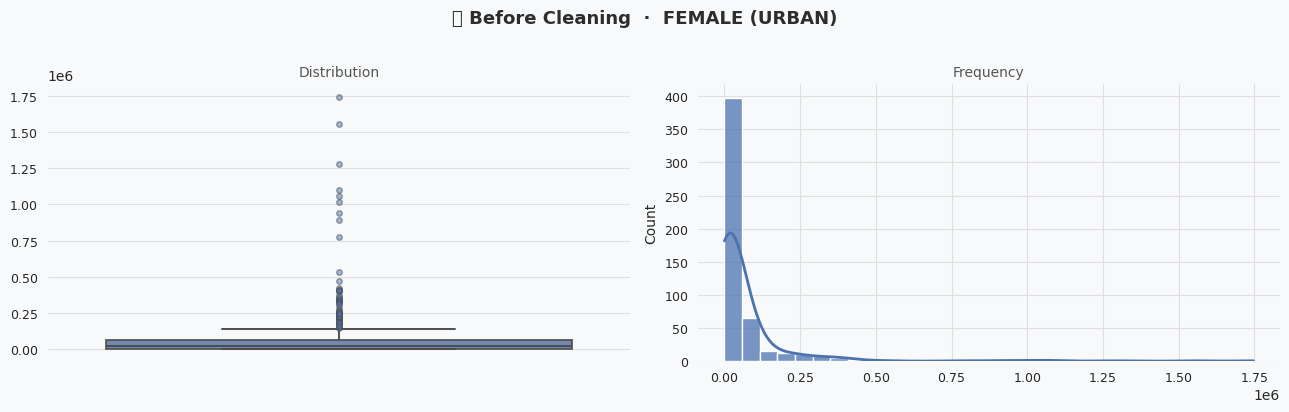

/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


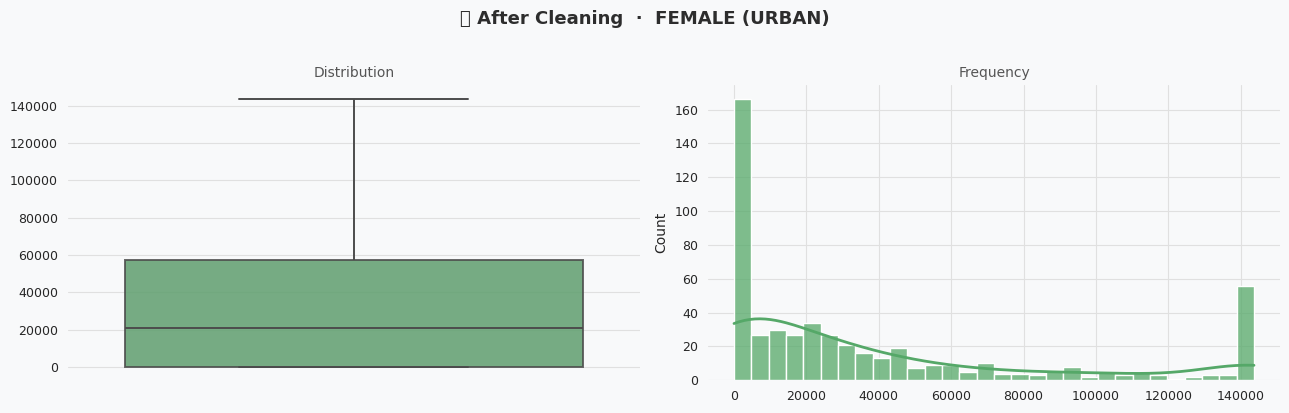


📊 Processing Column: TRANSGENDER (URBAN)
TRANSGENDER (URBAN) → Minimum: 0
TRANSGENDER (URBAN) → Q1: 0.0
TRANSGENDER (URBAN) → Median: 3.0
TRANSGENDER (URBAN) → Q3: 19.0
TRANSGENDER (URBAN) → Maximum: 795
TRANSGENDER (URBAN) → IQR: 19.0
TRANSGENDER (URBAN) → Lower Bound: -28.5
TRANSGENDER (URBAN) → Upper Bound: 47.5
TRANSGENDER (URBAN) → Outliers Count: 55


/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


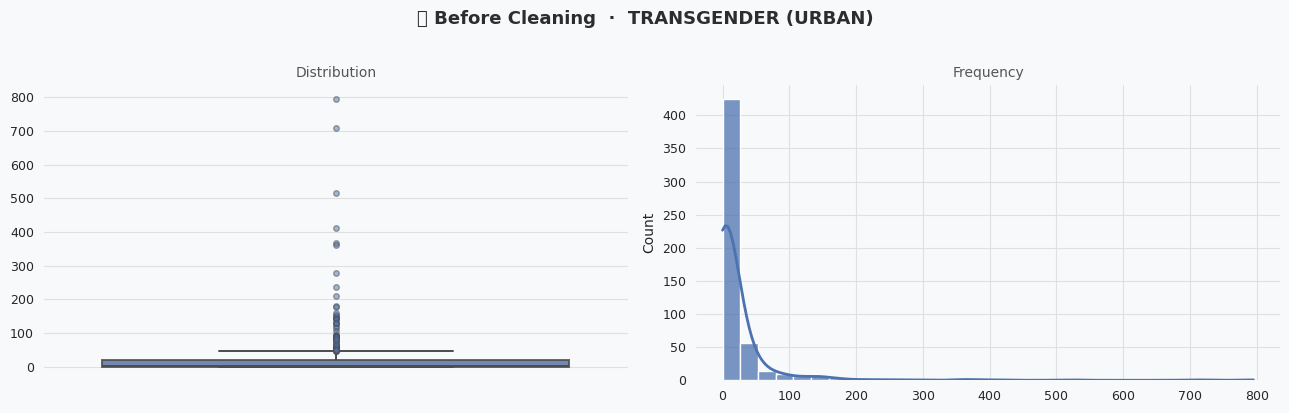

/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


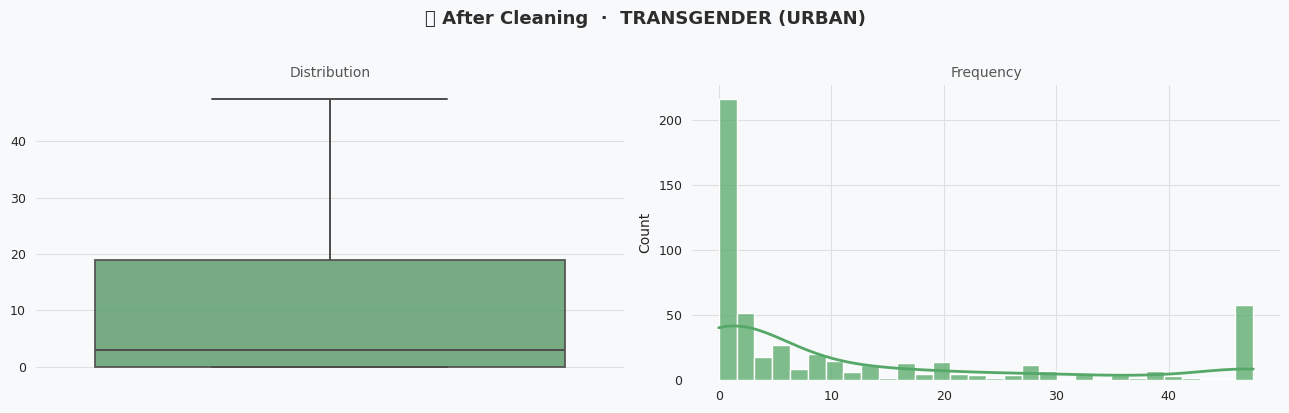


📊 Processing Column: SEX RATIO (URBAN)
SEX RATIO (URBAN) → Minimum: 0.0
SEX RATIO (URBAN) → Q1: 0.0
SEX RATIO (URBAN) → Median: 103.195
SEX RATIO (URBAN) → Q3: 107.04
SEX RATIO (URBAN) → Maximum: 297.81
SEX RATIO (URBAN) → IQR: 107.04
SEX RATIO (URBAN) → Lower Bound: -160.56
SEX RATIO (URBAN) → Upper Bound: 267.6
SEX RATIO (URBAN) → Outliers Count: 1


/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


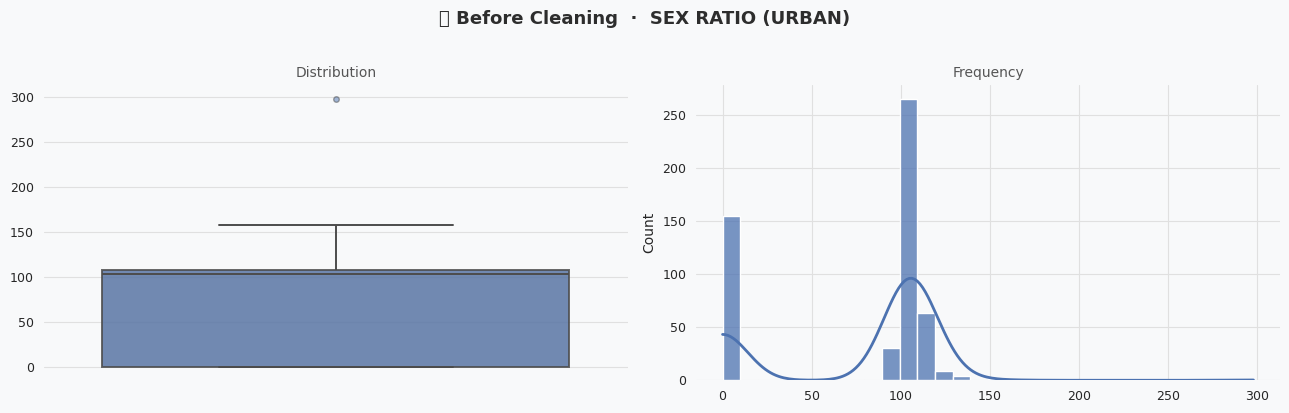

/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


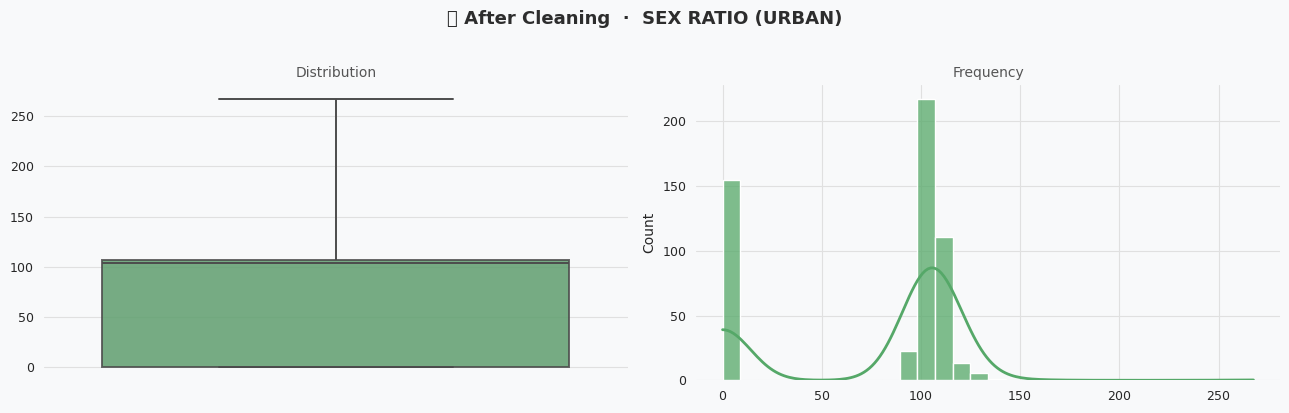


📊 Processing Column: AVG HOUSEHOLD SIZE (URBAN)
AVG HOUSEHOLD SIZE (URBAN) → Minimum: 0.0
AVG HOUSEHOLD SIZE (URBAN) → Q1: 0.0
AVG HOUSEHOLD SIZE (URBAN) → Median: 5.755
AVG HOUSEHOLD SIZE (URBAN) → Q3: 6.34
AVG HOUSEHOLD SIZE (URBAN) → Maximum: 10.06
AVG HOUSEHOLD SIZE (URBAN) → IQR: 6.34
AVG HOUSEHOLD SIZE (URBAN) → Lower Bound: -9.51
AVG HOUSEHOLD SIZE (URBAN) → Upper Bound: 15.85
AVG HOUSEHOLD SIZE (URBAN) → Outliers Count: 0


/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


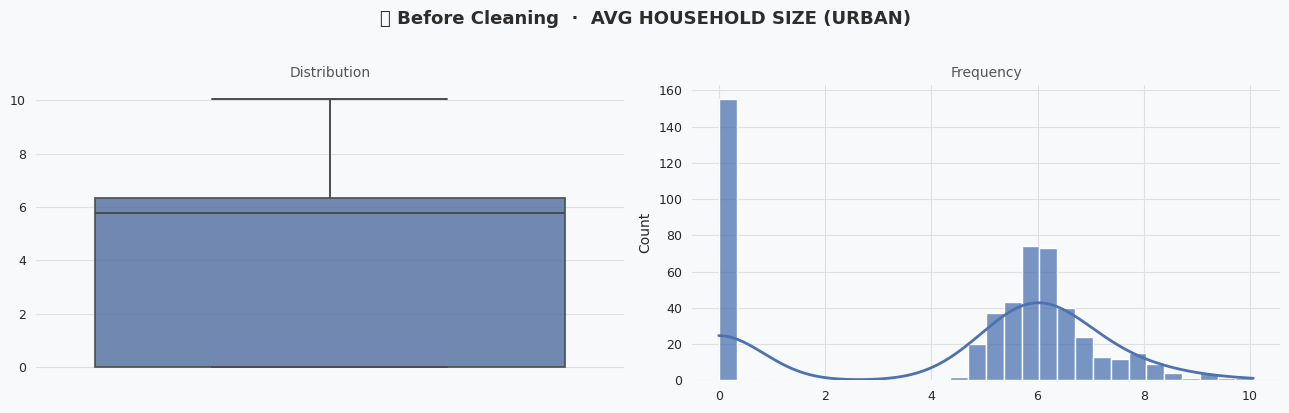

/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


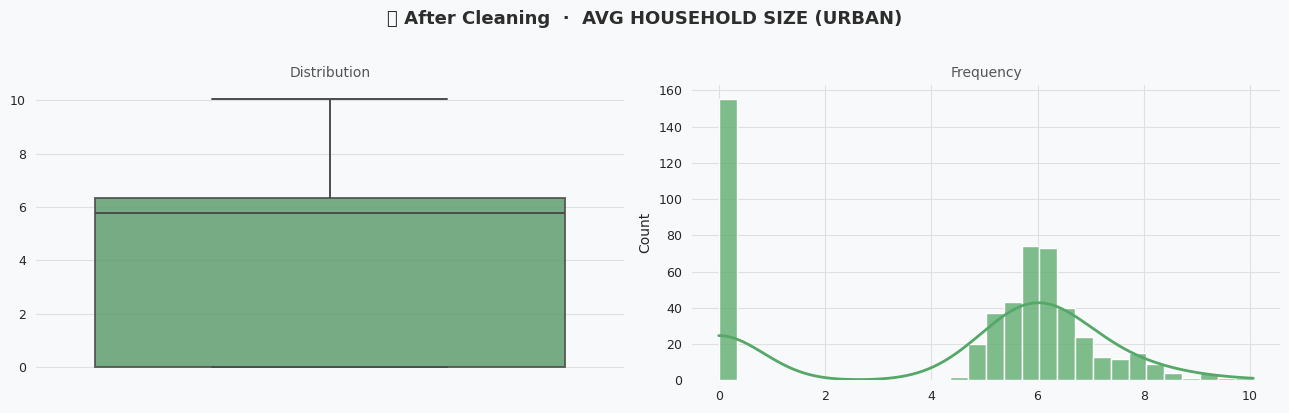


📊 Processing Column: POPULATION 1998 (URBAN)
POPULATION 1998 (URBAN) → Minimum: 0
POPULATION 1998 (URBAN) → Q1: 0.0
POPULATION 1998 (URBAN) → Median: 21298.0
POPULATION 1998 (URBAN) → Q3: 65422.25
POPULATION 1998 (URBAN) → Maximum: 2075867
POPULATION 1998 (URBAN) → IQR: 65422.25
POPULATION 1998 (URBAN) → Lower Bound: -98133.375
POPULATION 1998 (URBAN) → Upper Bound: 163555.625
POPULATION 1998 (URBAN) → Outliers Count: 56


/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


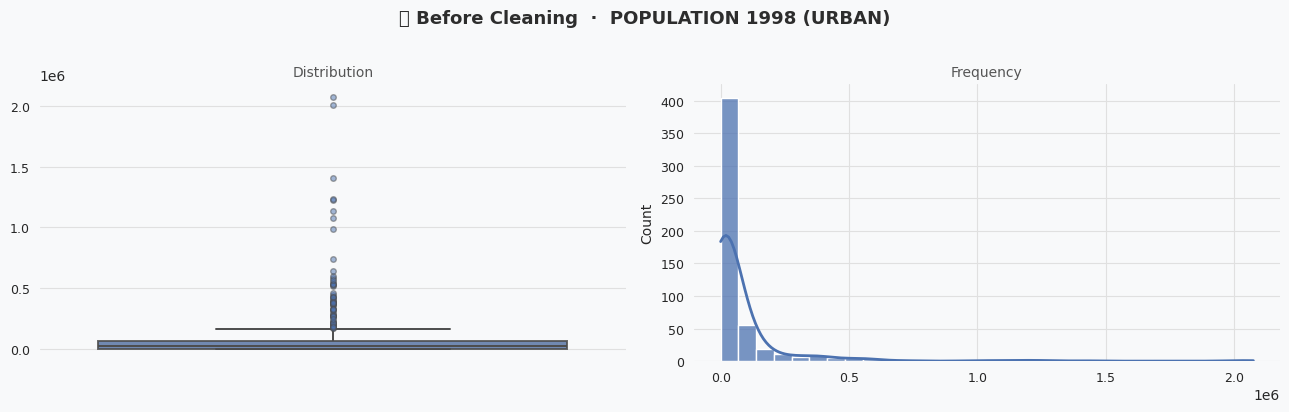

/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


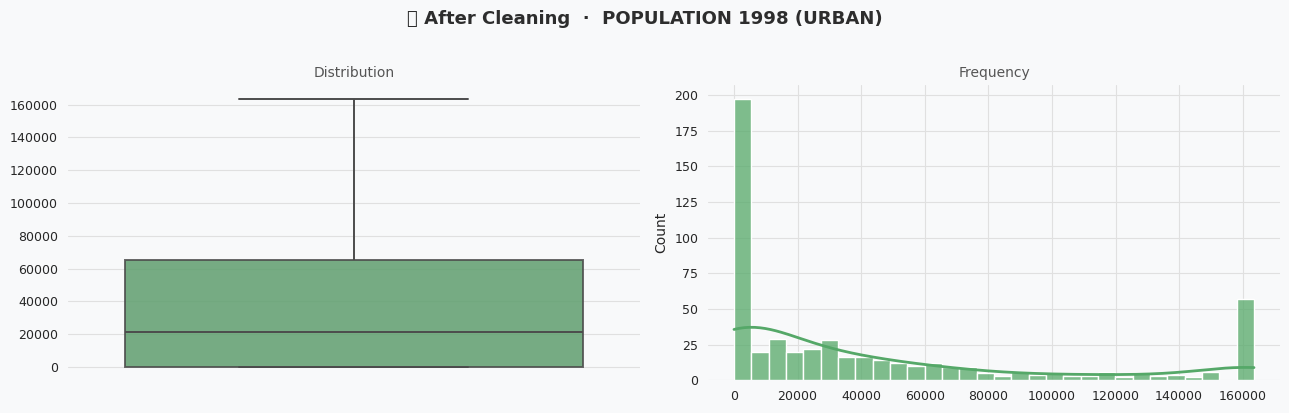


📊 Processing Column: ANNUAL GROWTH RATE (URBAN)
ANNUAL GROWTH RATE (URBAN) → Minimum: 0.0
ANNUAL GROWTH RATE (URBAN) → Q1: 0.0
ANNUAL GROWTH RATE (URBAN) → Median: 1.855
ANNUAL GROWTH RATE (URBAN) → Q3: 2.985
ANNUAL GROWTH RATE (URBAN) → Maximum: 19.78
ANNUAL GROWTH RATE (URBAN) → IQR: 2.985
ANNUAL GROWTH RATE (URBAN) → Lower Bound: -4.4775
ANNUAL GROWTH RATE (URBAN) → Upper Bound: 7.4625
ANNUAL GROWTH RATE (URBAN) → Outliers Count: 10


/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


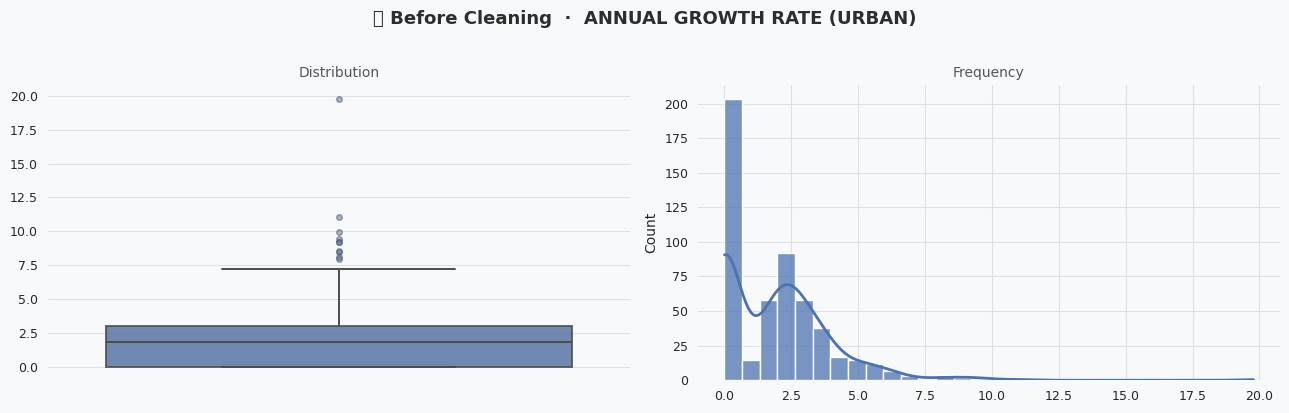

/tmp/ipykernel_28203/822654142.py:84: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/waseem/miniconda3/envs/pandas_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


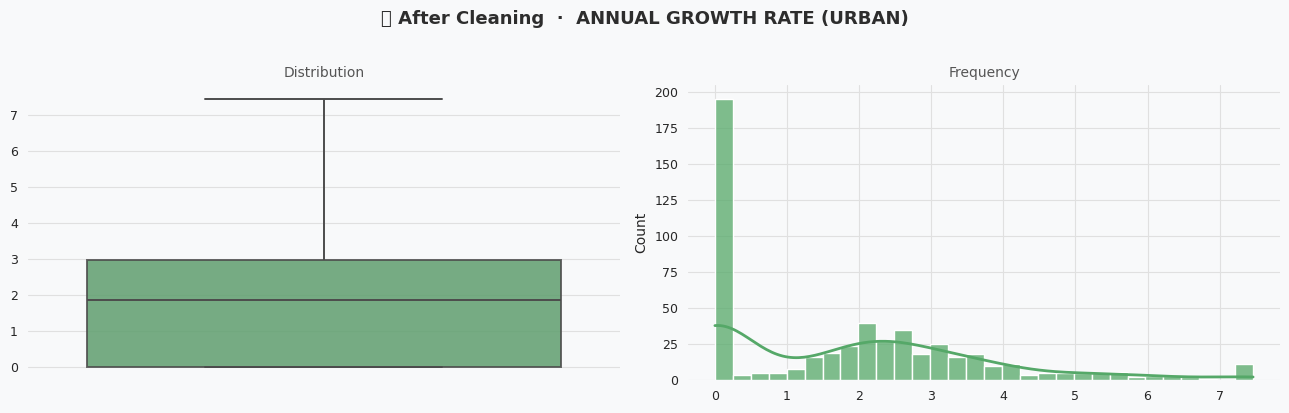

In [16]:
for col in df_copy.select_dtypes(include="number").columns:
    clean_data_from_outliers(col)

In [17]:
df.head()

,PROVINCE,DIVISION,DISTRICT,SUB DIVISION,AREA (sq.km),ALL SEXES (RURAL),MALE (RURAL),FEMALE (RURAL),TRANSGENDER (RURAL),SEX RATIO (RURAL),AVG HOUSEHOLD SIZE (RURAL),POPULATION 1998 (RURAL),ANNUAL GROWTH RATE (RURAL),ALL SEXES (URBAN),MALE (URBAN),FEMALE (URBAN),TRANSGENDER (URBAN),SEX RATIO (URBAN),AVG HOUSEHOLD SIZE (URBAN),POPULATION 1998 (URBAN),ANNUAL GROWTH RATE (URBAN)
0,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,BAHAWALNAGAR TEHSIL,1729.0,619550,316864,302644,42,104.70,6.10,407768,2.22,193840,98391,95402,47,103.13,6.02,133785,1.97
1,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,CHISHTIAN TEHSIL,1500.0,540342,273788,266500,54,102.73,6.15,395983,1.65,149424,75546,73851,27,102.30,6.01,102287,2.01
2,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,FORT ABBAS TEHSIL,2536.0,361240,182655,178541,44,102.30,6.32,250959,1.93,61528,31360,30150,18,104.01,6.00,34637,3.06
3,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,HAROONABAD TEHSIL,1295.0,382115,192278,189808,29,101.30,6.15,297343,1.33,142600,71345,71236,19,100.15,6.02,84424,2.79
4,PUNJAB,BAHAWALPUR DIVISION,BAHAWALNAGAR DISTRICT,MINCHINABAD TEHSIL,1818.0,452723,231506,221178,39,104.67,6.29,316593,1.90,72294,36694,35590,10,103.10,6.34,37668,3.48


In [18]:
df_copy.describe().T ## Transpose the data

,count,mean,std,min,25%,50%,75%,max
AREA (sq.km),528.0,1243.643655,1072.942827,0.00000,425.000,882.000,1734.2500,3698.12500
ALL SEXES (RURAL),528.0,226774.809422,210287.776823,0.00000,50934.500,165241.000,312911.2500,705876.37500
MALE (RURAL),528.0,115522.053504,106709.869347,0.00000,27127.250,84134.500,160502.2500,360564.75000
FEMALE (RURAL),528.0,111148.897727,103449.375361,0.00000,23979.000,82044.000,152219.0000,344579.00000
TRANSGENDER (RURAL),528.0,16.153409,18.140322,0.00000,1.000,10.000,25.0000,61.00000
SEX RATIO (RURAL),528.0,104.595530,7.040033,90.24125,101.105,105.285,108.3475,119.21125
AVG HOUSEHOLD SIZE (RURAL),528.0,6.472273,1.424794,3.45000,5.700,6.310,7.2000,9.45000
POPULATION 1998 (RURAL),528.0,154754.399858,142562.730924,0.00000,35273.500,117206.500,213054.2500,479725.37500
ANNUAL GROWTH RATE (RURAL),528.0,2.162976,1.171336,0.00000,1.440,2.030,2.8125,4.87125
ALL SEXES (URBAN),528.0,81147.932055,97228.673846,0.00000,0.000,43254.500,117814.7500,294536.87500


In [19]:
df_copy.count()

PROVINCE                      528
DIVISION                      528
DISTRICT                      528
SUB DIVISION                  528
AREA (sq.km)                  528
ALL SEXES (RURAL)             528
MALE (RURAL)                  528
FEMALE (RURAL)                528
TRANSGENDER (RURAL)           528
SEX RATIO (RURAL)             528
AVG HOUSEHOLD SIZE (RURAL)    528
POPULATION 1998 (RURAL)       528
ANNUAL GROWTH RATE (RURAL)    528
ALL SEXES (URBAN)             528
MALE (URBAN)                  528
FEMALE (URBAN)                528
TRANSGENDER (URBAN)           528
SEX RATIO (URBAN)             528
AVG HOUSEHOLD SIZE (URBAN)    528
POPULATION 1998 (URBAN)       528
ANNUAL GROWTH RATE (URBAN)    528
dtype: int64

In [20]:
df_copy.value_counts()

PROVINCE  DIVISION                   DISTRICT                   SUB DIVISION         AREA (sq.km)  ALL SEXES (RURAL)  MALE (RURAL)  FEMALE (RURAL)  TRANSGENDER (RURAL)  SEX RATIO (RURAL)  AVG HOUSEHOLD SIZE (RURAL)  POPULATION 1998 (RURAL)  ANNUAL GROWTH RATE (RURAL)  ALL SEXES (URBAN)  MALE (URBAN)  FEMALE (URBAN)  TRANSGENDER (URBAN)  SEX RATIO (URBAN)  AVG HOUSEHOLD SIZE (URBAN)  POPULATION 1998 (URBAN)  ANNUAL GROWTH RATE (URBAN)
PUNJAB    BAHAWALPUR DIVISION        BAHAWALNAGAR DISTRICT      BAHAWALNAGAR TEHSIL  1729.0        619550.0           316864.0      302644          42                   104.70000          6.10                        407768.0                 2.22                        193840.0           98391.0       95402.0         47.0                 103.13             6.02                        133785.0                 1.97                          1
                                                                CHISHTIAN TEHSIL     1500.0        540342.0           2

<Axes: xlabel='ALL SEXES (RURAL)', ylabel='DIVISION'>

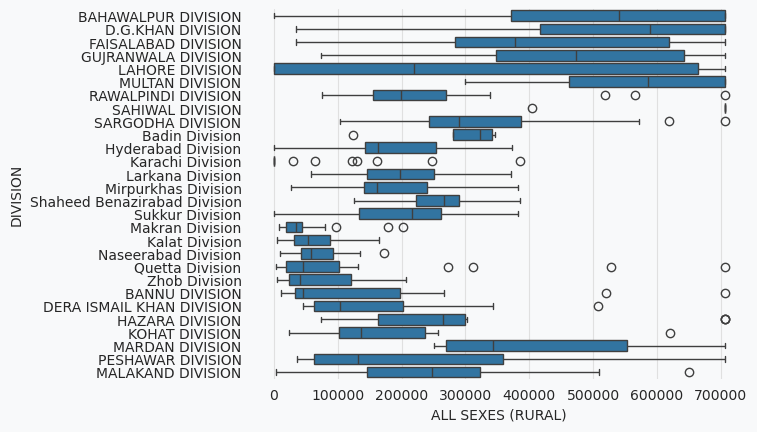

In [22]:
sns.boxplot(df_copy, x="ALL SEXES (RURAL)", y="DIVISION")

In [23]:
df["DIVISION"].describe()

count                 528
unique                 28
top       Quetta Division
freq                   38
Name: DIVISION, dtype: object

`Since this is hard to plot so we will use groupby function to make tabulated data output`

In [24]:
df_copy["DISTRICT"].unique()

<StringArray>
[    'BAHAWALNAGAR DISTRICT',       'BAHAWALPUR DISTRICT',
   'RAHIM YAR KHAN DISTRICT',  'DERA GHAZI KHAN DISTRICT',
           'LAYYAH DISTRICT',     'MUZAFFARGARH DISTRICT',
         'RAJANPUR DISTRICT',          'CHINIOT DISTRICT',
       'FAISALABAD DISTRICT',            'JHANG DISTRICT',
 ...
      'FR D.I.KHAN DISTRICT',         'FR KOHAT DISTRICT',
  'FR LAKKI MARWAT DISTRICT',      'FR PESHAWAR DISTRICT',
           'KHYBER DISTRICT',           'KURRAM DISTRICT',
          'MOHMAND DISTRICT', 'NORTH WAZIRISTAN DISTRICT',
          'ORAKZAI DISTRICT', 'SOUTH WAZIRISTAN DISTRICT']
Length: 131, dtype: str

In [25]:
df_copy["DIVISION"].unique()

<StringArray>
[         'BAHAWALPUR DIVISION',            'D.G.KHAN DIVISION',
          'FAISALABAD DIVISION',          'GUJRANWALA DIVISION',
              'LAHORE DIVISION',              'MULTAN DIVISION',
          'RAWALPINDI DIVISION',             'SAHIWAL DIVISION',
            'SARGODHA DIVISION',               'Badin Division',
           'Hyderabad Division',             'Karachi Division',
             'Larkana Division',          'Mirpurkhas Division',
 'Shaheed Benazirabad Division',              'Sukkur Division',
              'Makran Division',               'Kalat Division',
          'Naseerabad Division',              'Quetta Division',
                'Zhob Division',               'BANNU DIVISION',
    'DERA ISMAIL KHAN DIVISION',              'HAZARA DIVISION',
               'KOHAT DIVISION',              'MARDAN DIVISION',
            'PESHAWAR DIVISION',            'MALAKAND DIVISION']
Length: 28, dtype: str

In [25]:
df_copy["PROVINCE"].unique()

<StringArray>
['PUNJAB', 'SINDH', 'BALOCHISTAN', 'KPK', 'KPK/FATA']
Length: 5, dtype: str

In [28]:
df_copy.groupby(["DIVISION"]).size().sort_values(ascending=False)

DIVISION
Quetta Division                 38
Makran Division                 37
MALAKAND DIVISION               33
Hyderabad Division              30
Karachi Division                30
RAWALPINDI DIVISION             22
Larkana Division                21
GUJRANWALA DIVISION             20
Zhob Division                   19
Naseerabad Division             19
Mirpurkhas Division             18
Kalat Division                  18
Sukkur Division                 18
PESHAWAR DIVISION               18
LAHORE DIVISION                 17
SARGODHA DIVISION               17
FAISALABAD DIVISION             17
BAHAWALPUR DIVISION             15
DERA ISMAIL KHAN DIVISION       15
BANNU DIVISION                  15
Shaheed Benazirabad Division    15
HAZARA DIVISION                 15
D.G.KHAN DIVISION               14
KOHAT DIVISION                  14
MULTAN DIVISION                 14
MARDAN DIVISION                  7
SAHIWAL DIVISION                 7
Badin Division                   5
dtype: int6

In [32]:
df_copy.groupby("DIVISION")[["ALL SEXES (URBAN)", "ALL SEXES (RURAL)"]].size().sort_values(ascending=False).head(3)

DIVISION
Quetta Division      38
Makran Division      37
MALAKAND DIVISION    33
dtype: int64

In [36]:
df_copy.groupby(["DIVISION", "SUB DIVISION", "DISTRICT", "PROVINCE"])[["ALL SEXES (URBAN)", "ALL SEXES (RURAL)"]].size()

DIVISION             SUB DIVISION              DISTRICT                  PROVINCE   
BAHAWALPUR DIVISION  AHMADPUR EAST TEHSIL      BAHAWALPUR DISTRICT       PUNJAB         1
                     BAHAWALNAGAR TEHSIL       BAHAWALNAGAR DISTRICT     PUNJAB         1
                     BAHAWALPUR CITY TEHSIL    BAHAWALPUR DISTRICT       PUNJAB         1
                     BAHAWALPUR SADDAR TEHSIL  BAHAWALPUR DISTRICT       PUNJAB         1
                     CHISHTIAN TEHSIL          BAHAWALNAGAR DISTRICT     PUNJAB         1
                                                                                       ..
Zhob Division        QAMAR DIN KAREZ TEHSIL    ZHOB DISTRICT             BALOCHISTAN    1
                     SAMBAZA SUB-TEHSIL        ZHOB DISTRICT             BALOCHISTAN    1
                     SHERANI TEHSIL            SHERANI DISTRICT          BALOCHISTAN    1
                     SHINKI SUB-TEHSIL         KILLA SAIFULLAH DISTRICT  BALOCHISTAN    1
               

#### Total Population Per Province

In [39]:
df_copy.groupby("PROVINCE")[["ALL SEXES (URBAN)", "ALL SEXES (RURAL)"]].sum().sort_values(by="ALL SEXES (URBAN)", ascending=False)

,ALL SEXES (URBAN),ALL SEXES (RURAL)
PROVINCE,,
PUNJAB,1.975930e+07,6.073025e+07
SINDH,1.641664e+07,2.301164e+07
KPK,3.828458e+06,2.254530e+07
BALOCHISTAN,2.701853e+06,8.862149e+06
KPK/FATA,1.398660e+05,4.587753e+06
